Exercice 5

In [2]:

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
# Chargement des données
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"] = data.target
# Affichage des premières lignes
print("Aperçu des données:")
print(df.head())
print("\nInformations sur le dataset:")
print(df.info())

Aperçu des données:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   Av

1. Exploration Basique

In [5]:
# dimensions
print("Shapenombre de ligne et colonnes :", df.shape)

# colonnes
print("Colonnes:", df.columns)

# types
print(df.dtypes)

# valeurs manquantes
print(df.isnull().sum())

Shapenombre de ligne et colonnes : (20640, 9)
Colonnes: Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


2. Statistiques Descriptives

In [6]:
# stats globales
print(df.describe())

# moyenne prix
print("Moyenne prix:", df["MedHouseVal"].mean())

# âge moyen
print("Age moyen:", df["HouseAge"].mean())

# min / max
print(df.min())
print(df.max())

# écart-type
print(df.std())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

3. Visualisation Simple

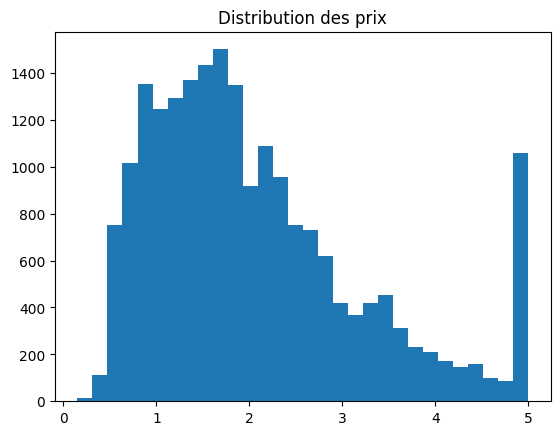

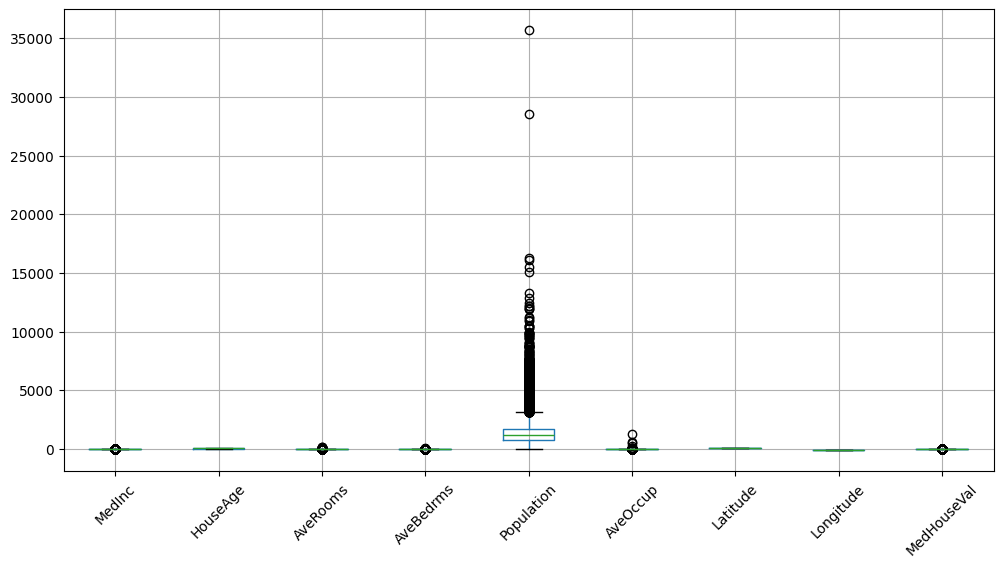

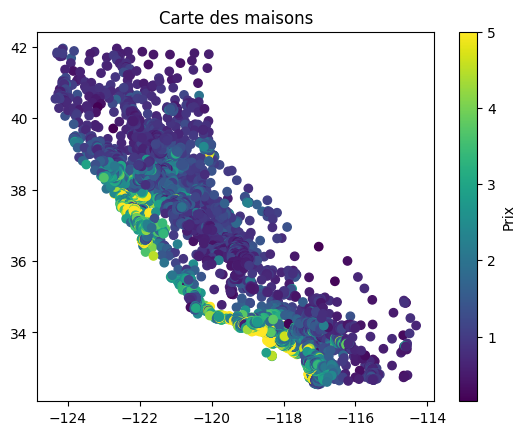

In [7]:
import matplotlib.pyplot as plt

# histogramme prix
plt.hist(df["MedHouseVal"], bins=30)
plt.title("Distribution des prix")
plt.show()

# boxplot
df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

# géographique
plt.scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"])
plt.colorbar(label="Prix")
plt.title("Carte des maisons")
plt.show()

4. analyse de relation

               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude    -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude   -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079809  -0.015176     0.688075  
HouseAge     0.011173  -0.108197     0.105623  
AveRooms     0.106389  -0.027540     0.151948  
AveBedrms    0.069721   0.0

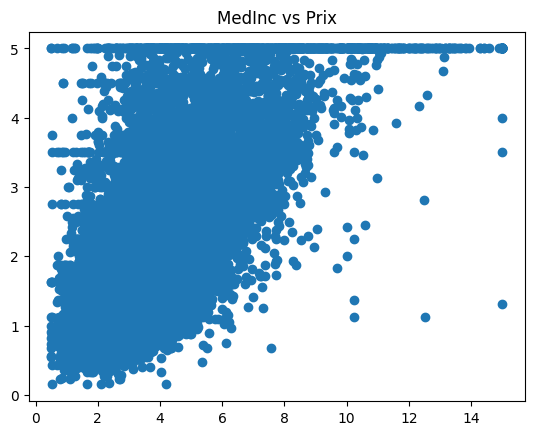

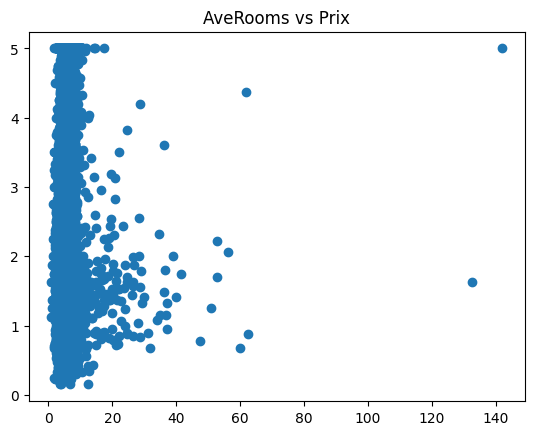

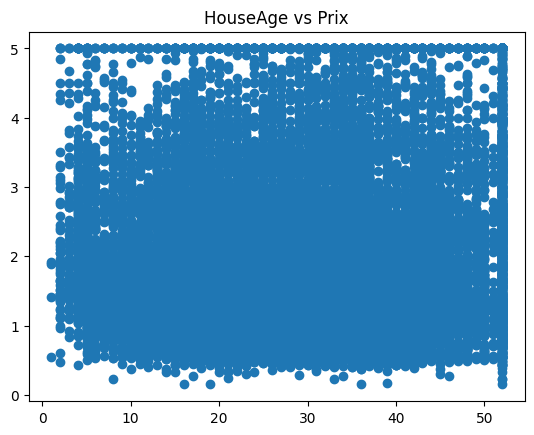

In [8]:
# corrélation
corr = df.corr()
print(corr)

# top 3 corrélations avec prix
top_corr = corr["MedHouseVal"].sort_values(ascending=False)
print(top_corr)

# scatter plots
features = top_corr.index[1:4]

for f in features:
    plt.scatter(df[f], df["MedHouseVal"])
    plt.title(f"{f} vs Prix")
    plt.show()

5. Analyse des Distributions

MedInc          1.646657
HouseAge        0.060331
AveRooms       20.697869
AveBedrms      31.316956
Population      4.935858
AveOccup       97.639561
Latitude        0.465953
Longitude      -0.297801
MedHouseVal     0.977763
dtype: float64


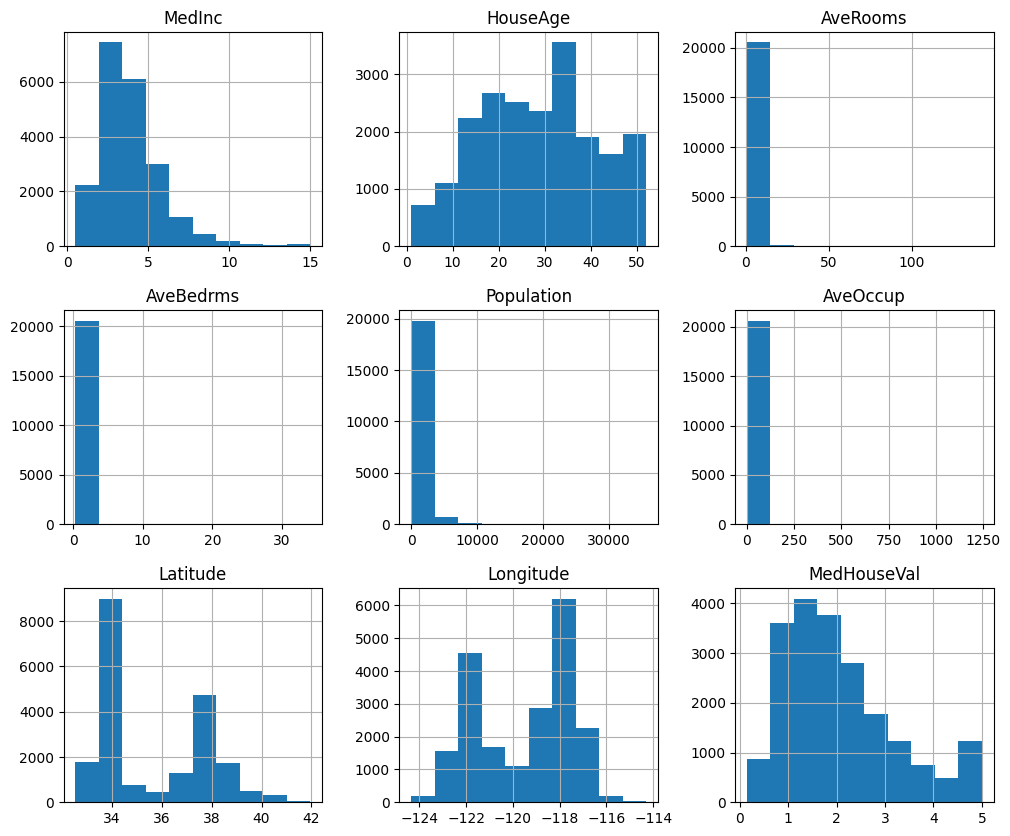

In [9]:
# skewness
print(df.skew())

# normalité (simple)
df.hist(figsize=(12,10))
plt.show()

6. Filtrage et Agrégation

In [10]:
# création région simple (approximation)
df["Region"] = pd.cut(df["Latitude"], bins=5, labels=False)

# prix moyen par région
print(df.groupby("Region")["MedHouseVal"].mean())

# filtrage
high_price = df[df["MedHouseVal"] > df["MedHouseVal"].mean()]
print(high_price.head())

# zones chères
print(df.groupby("Region")["MedHouseVal"].mean().sort_values())

Region
0    2.228903
1    1.403145
2    2.240963
3    1.413950
4    0.844997
Name: MedHouseVal, dtype: float64
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  Region  
0    -122.23        4.526       2  
1    -122.22        3.585       2  
2    -122.24        3.521       2  
3    -122.25        3.413       2  
4    -122.25        3.422       2  
Region
4    0.844997
1    1.403145
3    1.413950
0    2.228903
2    2.240963
Name: MedHouseVal, dtype: float64
